# derived_8.4-eval-2.0 — MLP Leave-One-Station-Out (LOSO) Spatial Generalization

Continuation of `derived_8.4-eval-1.2` (same output format) evaluating the **spatial generalization** of the MLP models established in `derived_8.4-eval-mlp-1.3` (2-regime) and `derived_8.4-eval-mlp-1.1` (1-regime) under a **leave-one-station-out** (LOSO) protocol on the 7 Washington stations of the `derived_8.4` split. Scope per the experiment brief: one regime (global single MLP) and two regimes — with only the **best clustering strategy** (`Clustering_V0_Full_k2`, c0=0, c1=10). The motivating hypothesis (from mlp-1.3's OOD finding) is that MLPs extrapolate smoothly in feature space and therefore generalize to unseen stations better than the XGBoost MoE baselines.

For each of the 6 pinned MLP configurations and each held-out station $s$: the router is refitted on the fold's trainval (6 remaining stations) and the specialists are trained per regime cluster on the fold's train split, early-stopped on the fold's val split (mlp-1.3 trainer, patience 60), then evaluated on all test rows of station $s$ (2023–2025). Per-configuration × per-station metrics are collected, so station difficulty is a direct byproduct. The XGBoost LOSO results from `derived_8.4-eval-1.2` are merged as reference rows (no retraining).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
from IPython.display import Image, display

# Robust resolution of the experiment dir whether executed from notebooks/ or in-place.
candidates = [Path.cwd() / "experiment/derived_8.4-eval-2.0", Path.cwd()]
EXP_DIR = next((p for p in candidates if (p / "loso_config_summary.csv").exists()), Path.cwd())

df_summary = pd.read_csv(EXP_DIR / "loso_config_summary.csv")
df_station = pd.read_csv(EXP_DIR / "loso_station_summary.csv")
df_pcs = pd.read_csv(EXP_DIR / "loso_per_config_station.csv")
df_regime = pd.read_csv(EXP_DIR / "loso_per_regime_metrics.csv")
df_year = pd.read_csv(EXP_DIR / "loso_per_year_metrics.csv")

n_mlp = df_summary["strategy_name"].str.startswith("MLP").sum()
n_xgb = (df_summary["strategy_name"] == "XGBoost_Reference").sum()
print(f"Loaded {len(df_summary)} leaderboard rows ({n_mlp} MLP + {n_xgb} XGBoost refs), "
      f"{len(df_station)} stations, {len(df_pcs)} config×station folds, "
      f"{len(df_regime)} regime rows, {len(df_year)} year rows.")

Loaded 8 leaderboard rows (6 MLP + 2 XGBoost refs), 7 stations, 56 config×station folds, 67 regime rows, 168 year rows.


## LOSO Configuration Leaderboard

Mean $R^2$ across the 7 held-out stations (each model trained on the other 6 stations, tested on the held-out one). `loso_mean_r2` is the average of per-station $R^2$; `loso_pooled_r2` is the sample-count-weighted $R^2$ over the concatenated 6,620 held-out test samples; `loso_min/max_r2` show the spread across stations. `temporal_test_r2` is the same configuration's *temporal* test $R^2$ from its source experiment (mlp-1.3 for the 2-regime rows, mlp-1.1 for the 1-regime rows, eval-1.1 for the XGBoost references); `loso_minus_test_r2` is the spatial-generalization gap. `is_winner` marks the val-selected winners per family.

In [2]:
show = df_summary.copy()
show["temporal_test_r2"] = show["ref_test_r2"]
leaderboard_cols = [
    "config_label", "strategy_name", "loso_mean_r2", "loso_pooled_r2", "loso_std_r2",
    "loso_min_r2", "loso_max_r2", "loso_mean_rmse", "loso_mean_bias", "temporal_test_r2",
    "loso_minus_test_r2", "is_winner",
]
print("### LOSO Configuration Leaderboard (mean R² over 7 held-out stations)")
print(show[leaderboard_cols].to_markdown(index=False))

### LOSO Configuration Leaderboard (mean R² over 7 held-out stations)
| config_label                                       | strategy_name     |   loso_mean_r2 |   loso_pooled_r2 |   loso_std_r2 |   loso_min_r2 |   loso_max_r2 |   loso_mean_rmse |   loso_mean_bias |   temporal_test_r2 |   loso_minus_test_r2 | is_winner   |
|:---------------------------------------------------|:------------------|---------------:|-----------------:|--------------:|--------------:|--------------:|-----------------:|-----------------:|-------------------:|---------------------:|:------------|
| XGBoost Clustering_V0_Full_k2 (Winner c0=0, c1=10) | XGBoost_Reference |       0.641545 |         0.688536 |      0.123588 |     0.427317  |      0.779948 |        0.0557425 |       0.0156391  |           0.81496  |            -0.173415 | False       |
| MLP 2-Regime-96 (w512x512x512_d0.3_lr1e-3)         | MLP_2regime_96    |       0.590332 |         0.66782  |      0.165357 |     0.316241  |      0.762384 |       

## Station Difficulty (Byproduct)

Aggregating LOSO $R^2$ over all configurations (6 MLP + 2 XGBoost references) per held-out station reveals which stations are harder to generalize to (fewer stations share their climate/soil regime). `n_negative_r2` counts configurations with negative $R^2$ for that station.

In [3]:
station_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
                "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("### Station Difficulty — LOSO R² aggregated over all configurations")
print(df_station[station_cols].to_markdown(index=False))

### Station Difficulty — LOSO R² aggregated over all configurations
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |    min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|----------:|---------:|------------:|------------:|----------------:|
| Paradise_WA           |           8 |           8536 |    0.721805 | 0.723385  | 0.0313034 |  0.688631 | 0.779948 |   0.0516859 |  0.00889874 |               0 |
| CayusePass_WA         |           8 |           8648 |    0.692666 | 0.644163  | 0.134763  |  0.347175 | 0.735079 |   0.0703204 |  0.0227201  |               0 |
| BeaverPass_WA_990     |           8 |           5008 |    0.677685 | 0.64756   | 0.0909142 |  0.489192 | 0.742395 |   0.0537133 | -0.00383816 |               0 |
| Spokane               |           8 |           7176 |    0.638757 | 0.639414  | 0.107416  |  0.482108 | 0.849

## Per-Configuration × Per-Station R² Matrix

Full LOSO $R^2$ matrix (rows = the 8 configurations, columns = held-out stations). This is the raw per-configuration metric collection that makes station difficulty directly attributable per model.

In [4]:
piv = df_pcs.pivot_table(index="config_label", columns="station", values="r2")
station_order = df_station.sort_values("median_r2", ascending=False)["station"].tolist()
piv = piv[station_order]
print("### LOSO R² — Configuration × Held-out Station")
print(piv.to_markdown())

### LOSO R² — Configuration × Held-out Station
| config_label                                       |   Paradise_WA |   CayusePass_WA |   BeaverPass_WA_990 |   Spokane |   Darrington |   SourdoughGulch_WA_985 |   Quinault |
|:---------------------------------------------------|--------------:|----------------:|--------------------:|----------:|-------------:|------------------------:|-----------:|
| MLP 1-Regime-54 (w256x256_d0.3_tanh)               |      0.688631 |        0.543223 |            0.665595 |  0.849249 |     0.302055 |               0.524803  |  0.180091  |
| MLP 1-Regime-96 (res_w512x512_d0.2_wd1e-3)         |      0.709071 |        0.688647 |            0.566318 |  0.647031 |     0.71893  |               0.417498  | -1.5084    |
| MLP 2-Regime-54 (w384x384_d0.3_gelu)               |      0.700866 |        0.720341 |            0.689775 |  0.703423 |     0.387842 |              -0.144557  |  0.314888  |
| MLP 2-Regime-54 (w448x448_d0.3_gelu)               |      0.691917

## Per-Regime (Cluster) Breakdown under LOSO

Cluster-level metrics on the held-out stations for the **winning** configurations only (the val-selected winners per family, marked `is_winner`). Regimes are the $K=2$ partitions produced by the `Clustering_V0_Full_k2` router, refitted on the 6 training stations per fold; 1-regime configs have a single cluster.

In [5]:
winners = df_summary.loc[df_summary["is_winner"], "config_id"].tolist()
df_w = df_regime[df_regime["config_id"].isin(winners)].copy()
df_w = df_w.merge(df_summary[["config_id", "config_label"]], on="config_id", how="left")
regime_cols = ["config_label", "station", "cluster", "n_train", "n_test", "r2", "rmse", "ubrmse", "bias", "mae"]
print("### Per-Regime LOSO Metrics (winning configurations)")
print(df_w[regime_cols].to_markdown(index=False))

### Per-Regime LOSO Metrics (winning configurations)
| config_label                                 | station               |   cluster |   n_train |   n_test |          r2 |      rmse |    ubrmse |        bias |       mae |
|:---------------------------------------------|:----------------------|----------:|----------:|---------:|------------:|----------:|----------:|------------:|----------:|
| MLP 1-Regime-54 (w256x256_d0.3_tanh)         | BeaverPass_WA_990     |         0 |      8344 |      626 |   0.665595  | 0.0526883 | 0.0503798 |  0.0154252  | 0.0409934 |
| MLP 1-Regime-54 (w256x256_d0.3_tanh)         | CayusePass_WA         |         0 |      8389 |     1081 |   0.543223  | 0.0807183 | 0.0677131 |  0.0439361  | 0.0669413 |
| MLP 1-Regime-54 (w256x256_d0.3_tanh)         | Darrington            |         0 |      8426 |      999 |   0.302055  | 0.0780553 | 0.0729283 |  0.0278224  | 0.0616319 |
| MLP 1-Regime-54 (w256x256_d0.3_tanh)         | Paradise_WA           |         0 |   

## Yearly Breakdown under LOSO

For each configuration, mean held-out-station $R^2$ per test year (2023–2025). Aggregated over the 7 stations, this shows how spatial generalization evolves over time.

In [6]:
df_y = df_year.groupby(["config_id", "year"])["r2"].mean().reset_index()
df_y = df_y.merge(df_summary[["config_id", "config_label", "strategy_name"]], on="config_id", how="left")
year_piv = df_y.pivot_table(index="config_label", columns="year", values="r2")
year_piv = year_piv.reindex(df_summary["config_label"].tolist())
print("### Yearly Mean LOSO R² by Configuration")
print(year_piv.to_markdown())

### Yearly Mean LOSO R² by Configuration
| config_label                                       |     2023 |       2024 |       2025 |
|:---------------------------------------------------|---------:|-----------:|-----------:|
| XGBoost Clustering_V0_Full_k2 (Winner c0=0, c1=10) | 0.476123 |  0.667421  |  -0.497154 |
| MLP 2-Regime-96 (w512x512x512_d0.3_lr1e-3)         | 0.509212 |  0.501302  |  -6.1404   |
| XGBoost Global Single (54 Backbone)                | 0.369052 |  0.601446  |  -0.233099 |
| MLP 1-Regime-54 (w256x256_d0.3_tanh)               | 0.401793 |  0.445885  |  -0.798375 |
| MLP 2-Regime-54 (w384x384_d0.3_gelu)               | 0.498339 |  0.358272  |  -2.23216  |
| MLP 2-Regime-54 (w512x512x512_d0.3_huber0.1)       | 0.47772  |  0.394558  |  -1.52037  |
| MLP 2-Regime-54 (w448x448_d0.3_gelu)               | 0.466509 |  0.198695  |  -2.8819   |
| MLP 1-Regime-96 (res_w512x512_d0.2_wd1e-3)         | 0.399127 | -0.0626779 | -12.0255   |


## Figures

Four figures summarize the LOSO results: (1) configuration × station $R^2$ heatmap, (2) LOSO-mean $R^2$ bar chart per configuration with per-station min/max whiskers, (3) station difficulty bar chart, and (4) boxplot of per-configuration $R^2$ per held-out station.

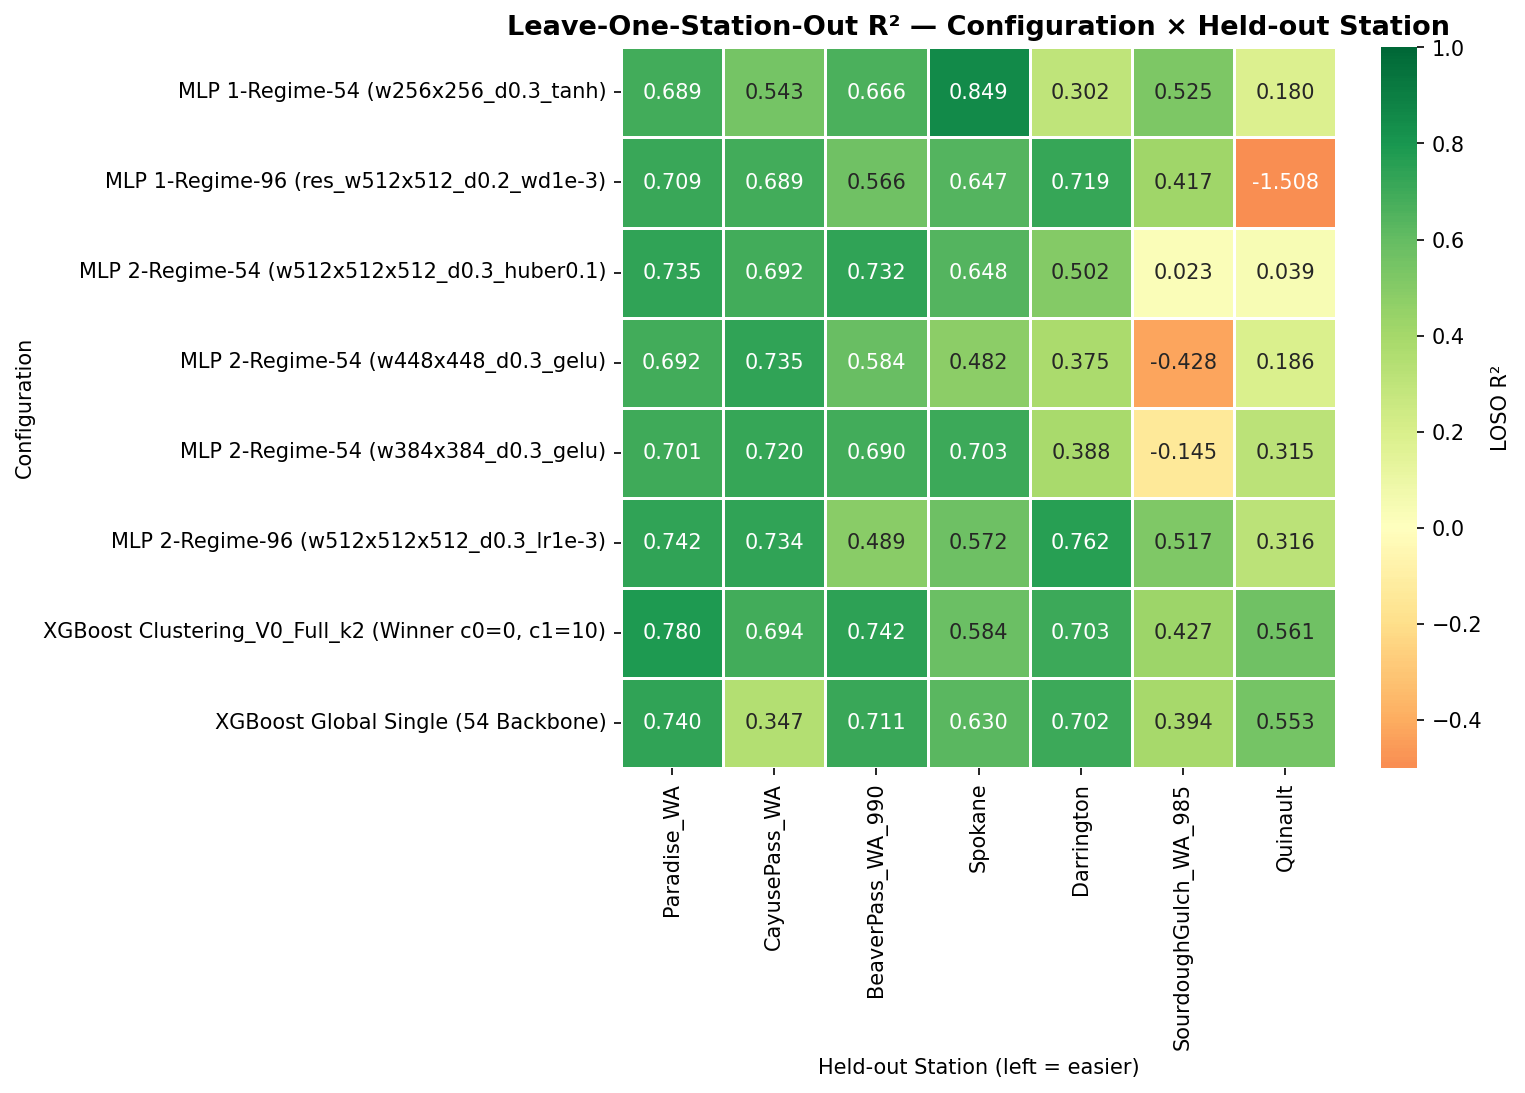

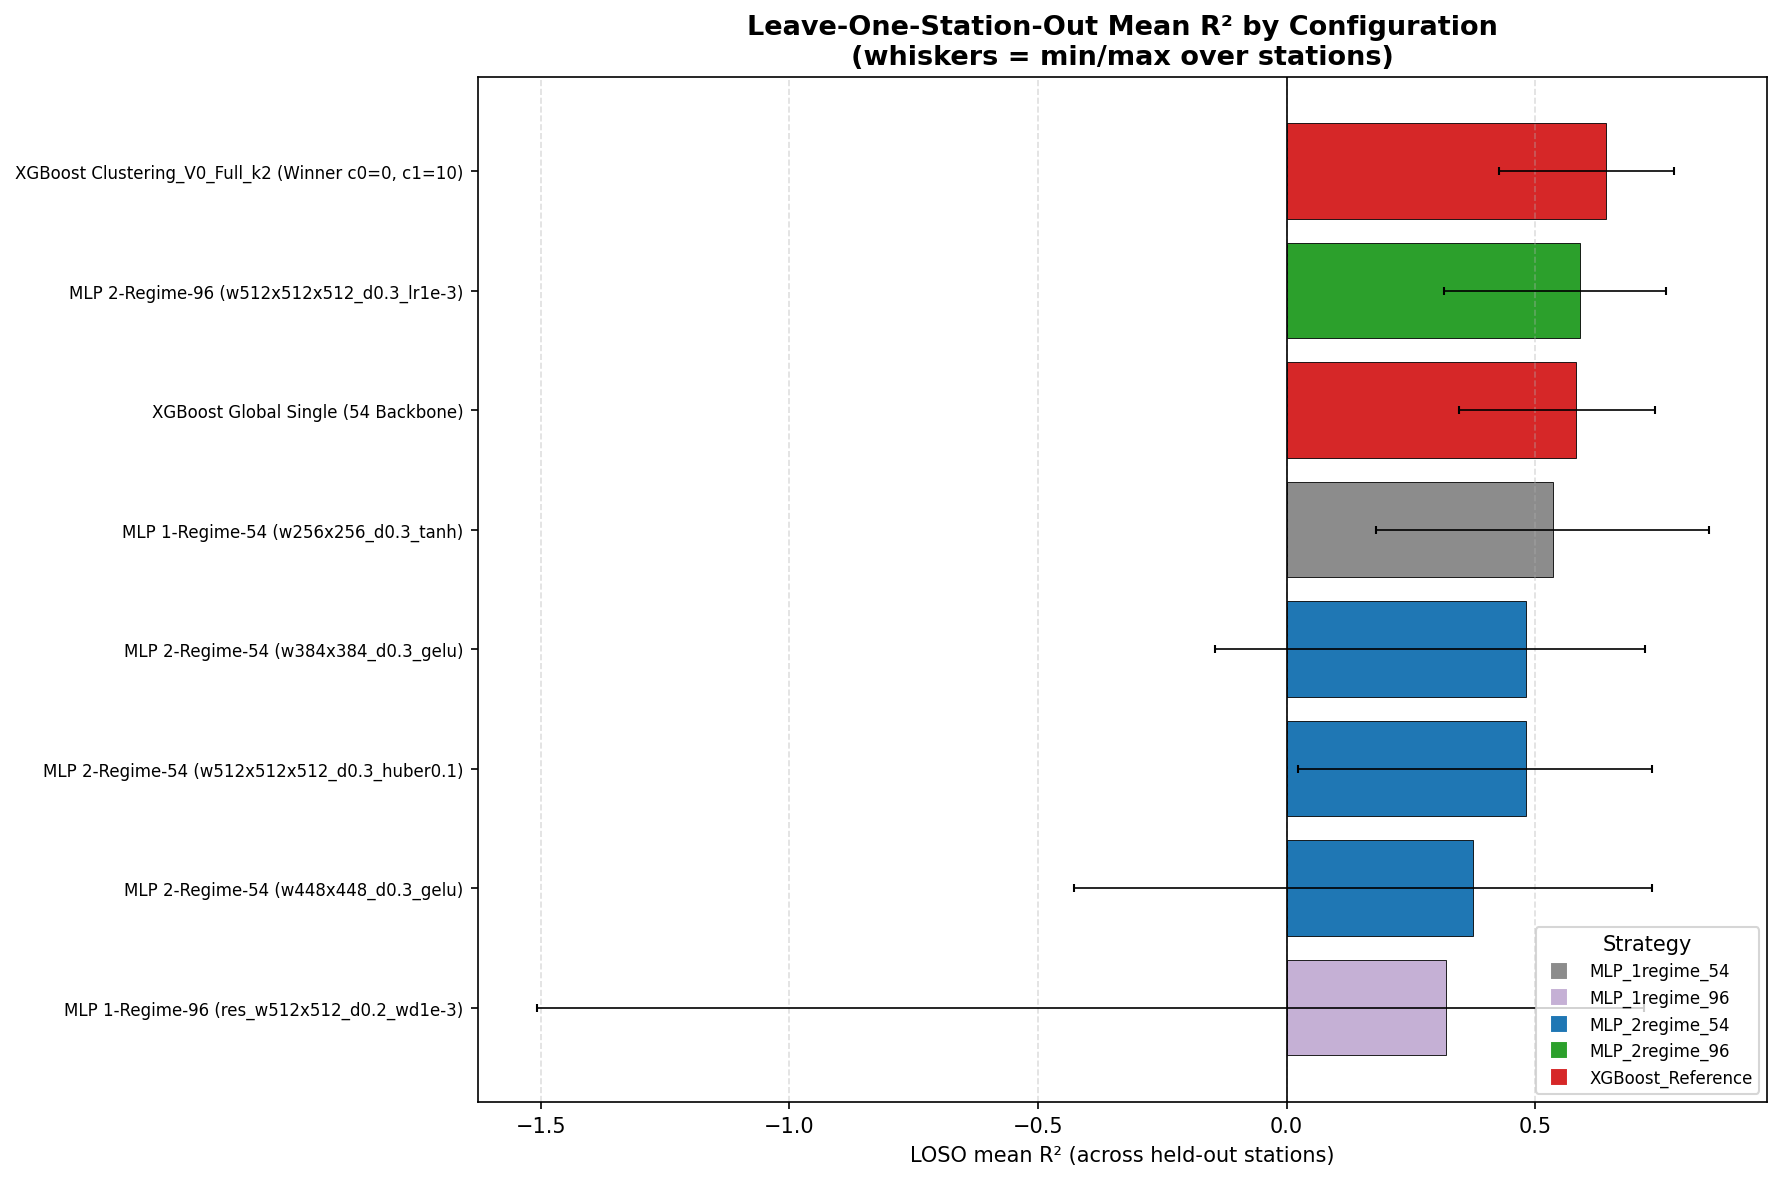

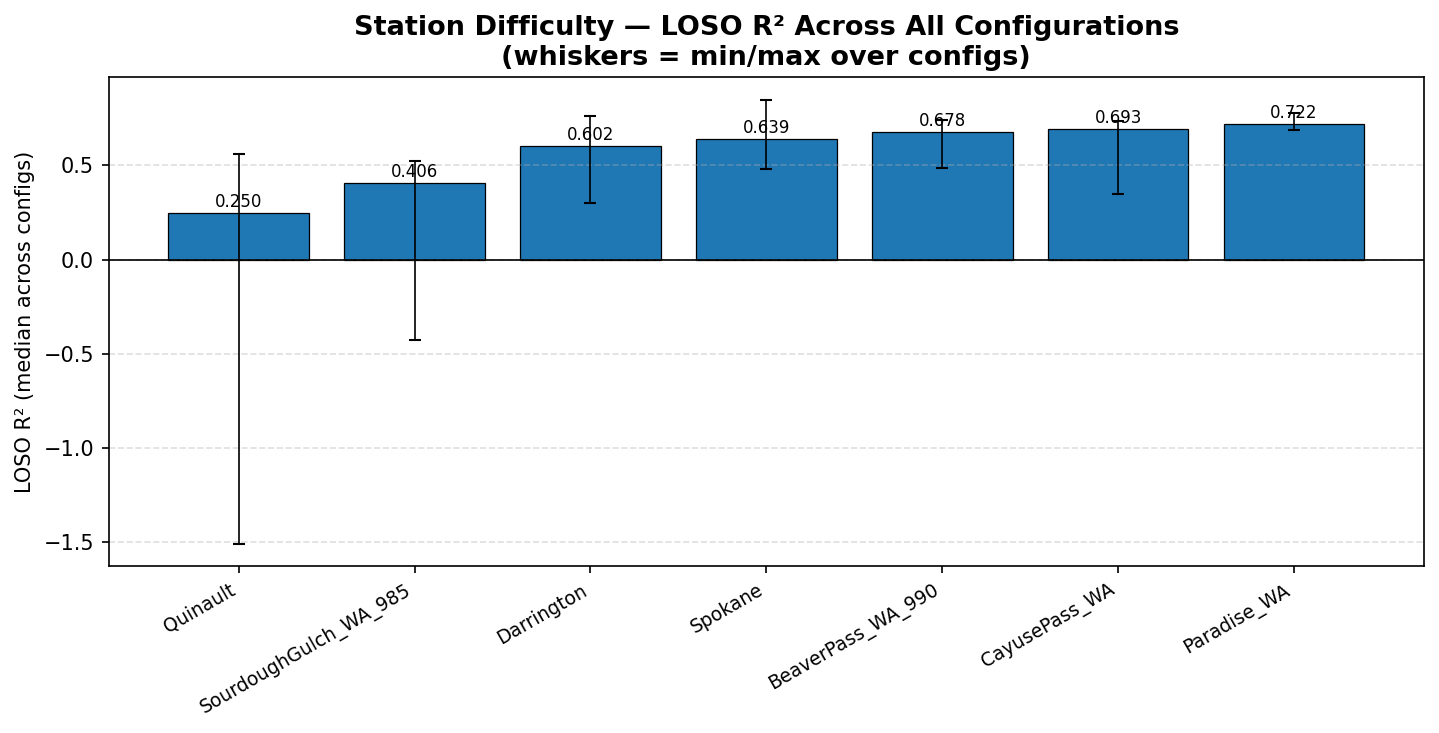

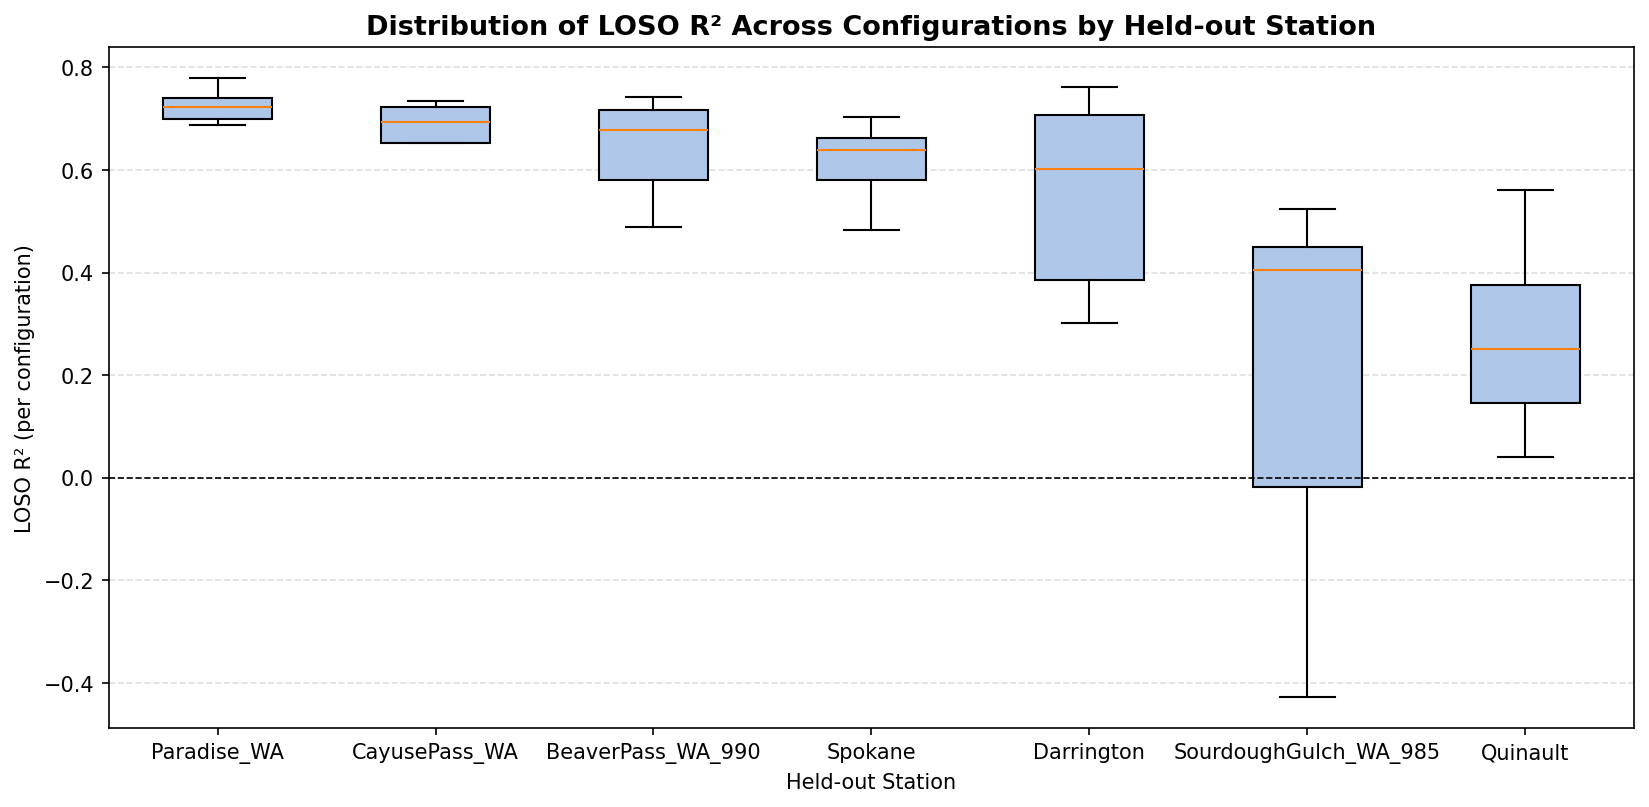

In [7]:
for fig in [
    "loso_r2_config_station_heatmap.png",
    "loso_r2_config_summary.png",
    "loso_station_difficulty.png",
    "loso_r2_station_boxplot.png",
]:
    display(Image(filename=str(EXP_DIR / fig)))

## Station Similarity & Clustering — Spatial-Generalization Hypothesis

**Hypothesis.** A station generalizes well spatially when the LOSO training set contains another station with *similar climate and geography* ("a twin"), and poorly when the station *stands out* from the rest. This section reuses `derived_8.4-eval-1.2`'s `eval12.station_sim` module: per-station feature vectors — WorldClim BioClim BIO1-19, geography, soil texture from `data/splits/derived_8.4/station_static_features.csv`, plus observed climatology (mean/std of precip, LST, NDVI, SMAP, soil moisture over train+val) — then Ward clustering + PCA, per-station isolation scores, and a Spearman hypothesis test against two LOSO difficulty measures: the median R² over the configurations and the per-station R² of the best 2-regime MLP spatial generalizer (`winner_r2`).

In [8]:
import sys
import yaml

# eval12.station_sim lives in derived_8.4-eval-1.2 (reused read-only).
sys.path.insert(0, str(EXP_DIR.parent / "derived_8.4-eval-1.2"))
from eval12 import station_sim as ss  # noqa: E402

with open(EXP_DIR / "config.yaml") as f:
    _cfg = yaml.safe_load(f)
PROJECT_ROOT = EXP_DIR.parents[2]

feats = ss.build_station_features(PROJECT_ROOT, _cfg)
print(f"Feature sets: {len(ss.GEO_FEATURES)} geography, {len(ss.BIOCLIM_FEATURES)} BioClim, "
      f"{len(ss.SOIL_FEATURES)} soil, {len(ss.DYNAMIC_FEATURES)} observed-climatology "
      f"({len(ss.STATIC_FEATURES) + len(ss.DYNAMIC_FEATURES)} total).")
print(f"Land cover: {dict(feats.landcover)}")

diff = ss.load_difficulty(EXP_DIR)
# winner_r2 = per-station R2 of the best 2-regime MLP spatial generalizer.
best2 = df_summary[df_summary["strategy_name"].isin(["MLP_2regime_54", "MLP_2regime_96"])] \
    .sort_values("loso_mean_r2", ascending=False).iloc[0]
win = df_pcs[df_pcs["config_id"] == best2["config_id"]].set_index("station")["r2"]
diff["winner_r2"] = diff.index.map(win)
diff["winner_config"] = best2["config_label"]
print(f"Winner config used for `winner_r2`: {diff['winner_config'].iloc[0]}")

profile = ss.station_profile_table(feats, {"median_r2": diff["median_r2"]})
print("\n### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)")
print(profile.to_markdown())

Feature sets: 6 geography, 19 BioClim, 4 soil, 10 observed-climatology (39 total).
Land cover: {'Spokane': 'Tree cover', 'Darrington': 'Tree cover', 'Quinault': 'Tree cover', 'SourdoughGulch_WA_985': 'Grassland', 'BeaverPass_WA_990': 'Tree cover', 'CayusePass_WA': 'Tree cover', 'Paradise_WA': 'Tree cover'}
Winner config used for `winner_r2`: MLP 2-Regime-96 (w512x512x512_d0.3_lr1e-3)

### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)
| station_id            | landcover   |   latitude |   longitude |   J_elev_m |   J_slope_deg |   J_bio_bio01 |   J_bio_bio12 |   J_sand_wfrac_b0 |   J_clay_wfrac_b0 |   mean_precip_mm |   mean_LST_modis |   mean_F_NDVI |   mean_soil_moisture_5cm |   median_r2 |
|:----------------------|:------------|-----------:|------------:|-----------:|--------------:|--------------:|--------------:|------------------:|------------------:|-----------------:|-----------------:|--------------:|-------------------------:|------------:|
| Spokane 

### Pairwise station distance

Euclidean distance on the z-scored 39-feature vector (29 static + 10 observed climatology). `nn_dist` (1-NN) is the distance to the closest *other* station — a small value means the station has a climate/geography "twin" in the dataset.

In [9]:
X_std = ss.standardize(feats.combined)
dist = ss.pairwise_distance(X_std)
print("### Pairwise Euclidean distance (standardized static + observed features)")
print(dist.round(2).to_markdown())

### Pairwise Euclidean distance (standardized static + observed features)
| station_id            |   Spokane |   Darrington |   Quinault |   SourdoughGulch_WA_985 |   BeaverPass_WA_990 |   CayusePass_WA |   Paradise_WA |
|:----------------------|----------:|-------------:|-----------:|------------------------:|--------------------:|----------------:|--------------:|
| Spokane               |      0    |         9.57 |      12.85 |                    4.14 |               10.56 |           11.06 |         11.56 |
| Darrington            |      9.57 |         0    |       7.58 |                    9.39 |                8.14 |            8.64 |          8.92 |
| Quinault              |     12.85 |         7.58 |       0    |                   12.64 |               11.59 |           10.17 |          9.05 |
| SourdoughGulch_WA_985 |      4.14 |         9.39 |      12.64 |                    0    |                9.86 |           10.31 |         10.94 |
| BeaverPass_WA_990     |     10.56 | 

### Hierarchical clustering and PCA

Ward linkage on the same standardized features; flat cluster assignments at k = 2 and k = 3 (k = 2 mirrors the MoE routers' two-regime split). PCA gives a 2-D view of the station embedding.

In [10]:
Z = ss.ward_linkage(X_std)
order = ss.leaf_order(Z, list(X_std.index))
print("Dendrogram leaf order:", order)
for k in (2, 3):
    print(f"\n### Ward clusters (k={k})")
    cl = ss.cluster_labels(Z, k, list(X_std.index)).to_frame("cluster")
    cl["median_r2"] = diff["median_r2"]
    print(cl.to_markdown())
scores, ev, loadings = ss.pca_projection(X_std)
print(f"\nPCA explained variance: PC1 = {ev[0]:.1%}, PC2 = {ev[1]:.1%} (total {ev.sum():.1%})")

Dendrogram leaf order: ['Spokane', 'SourdoughGulch_WA_985', 'Darrington', 'Quinault', 'BeaverPass_WA_990', 'CayusePass_WA', 'Paradise_WA']

### Ward clusters (k=2)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.638757 |
| Darrington            |         2 |    0.602296 |
| Quinault              |         2 |    0.250294 |
| SourdoughGulch_WA_985 |         1 |    0.405538 |
| BeaverPass_WA_990     |         2 |    0.677685 |
| CayusePass_WA         |         2 |    0.692666 |
| Paradise_WA           |         2 |    0.721805 |

### Ward clusters (k=3)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.638757 |
| Darrington            |         2 |    0.602296 |
| Quinault              |         2 |    0.250294 |
| SourdoughGulch_WA_985 |         1 |    0.405538 |
| BeaverPass_WA_990     |      

In [11]:
iso = ss.isolation_scores(X_std)
tbl = iso.join(diff[["median_r2", "mean_r2", "winner_r2"]])
tbl = tbl.sort_values("median_r2", ascending=False)
print("\n### Isolation metrics vs LOSO difficulty")
print(tbl.round(3).to_markdown())
print("\n### Spearman rank correlation (isolation × difficulty)")
print(ss.spearman_table(iso, diff).to_markdown(index=False))


### Isolation metrics vs LOSO difficulty
| station_id            |   nn_dist |   mean_dist |   centroid_dist |   median_r2 |   mean_r2 |   winner_r2 |
|:----------------------|----------:|------------:|----------------:|------------:|----------:|------------:|
| Paradise_WA           |     2.23  |       8.331 |           5.343 |       0.722 |     0.723 |       0.742 |
| CayusePass_WA         |     2.23  |       8.16  |           5.094 |       0.693 |     0.644 |       0.734 |
| BeaverPass_WA_990     |     6.546 |       8.996 |           5.759 |       0.678 |     0.648 |       0.489 |
| Spokane               |     4.138 |       9.956 |           7.254 |       0.639 |     0.639 |       0.572 |
| Darrington            |     7.58  |       8.705 |           5.134 |       0.602 |     0.557 |       0.762 |
| SourdoughGulch_WA_985 |     4.138 |       9.546 |           6.71  |       0.406 |     0.216 |       0.517 |
| Quinault              |     7.58  |      10.649 |           7.831 |       0.

In [12]:
# Sensitivity: static features only (geography + BioClim + soil; no target-derived
# observed climatology) — confirms the correlation pattern is not an artifact of
# including mean/std soil moisture in the feature vector.
X_static = ss.standardize(feats.static)
iso_static = ss.isolation_scores(X_static)
print("### Sensitivity — static features only (geography + BioClim + soil)")
print(ss.spearman_table(iso_static, diff).to_markdown(index=False))

### Sensitivity — static features only (geography + BioClim + soil)
| isolation_metric   | difficulty_metric   |   spearman_rho |   p_value |   n |
|:-------------------|:--------------------|---------------:|----------:|----:|
| nn_dist            | median_r2           |         -0.532 |     0.219 |   7 |
| nn_dist            | mean_r2             |         -0.33  |     0.469 |   7 |
| nn_dist            | winner_r2           |         -0.477 |     0.279 |   7 |
| mean_dist          | median_r2           |         -0.786 |     0.036 |   7 |
| mean_dist          | mean_r2             |         -0.679 |     0.094 |   7 |
| mean_dist          | winner_r2           |         -0.714 |     0.071 |   7 |
| centroid_dist      | median_r2           |         -0.536 |     0.215 |   7 |
| centroid_dist      | mean_r2             |         -0.464 |     0.294 |   7 |
| centroid_dist      | winner_r2           |         -0.821 |     0.023 |   7 |


### Figures

Five figures summarize the station similarity structure and the hypothesis test: (1) pairwise similarity heatmap in dendrogram order, (2) Ward dendrogram with leaf colors by difficulty tier, (3) PCA embedding colored by median LOSO R² with the top feature loadings, (4) isolation-vs-difficulty scatter (1-NN / mean distance × median / winner-config R², Spearman ρ annotated), and (5) the standardized feature matrix showing which features make the hard stations extreme.

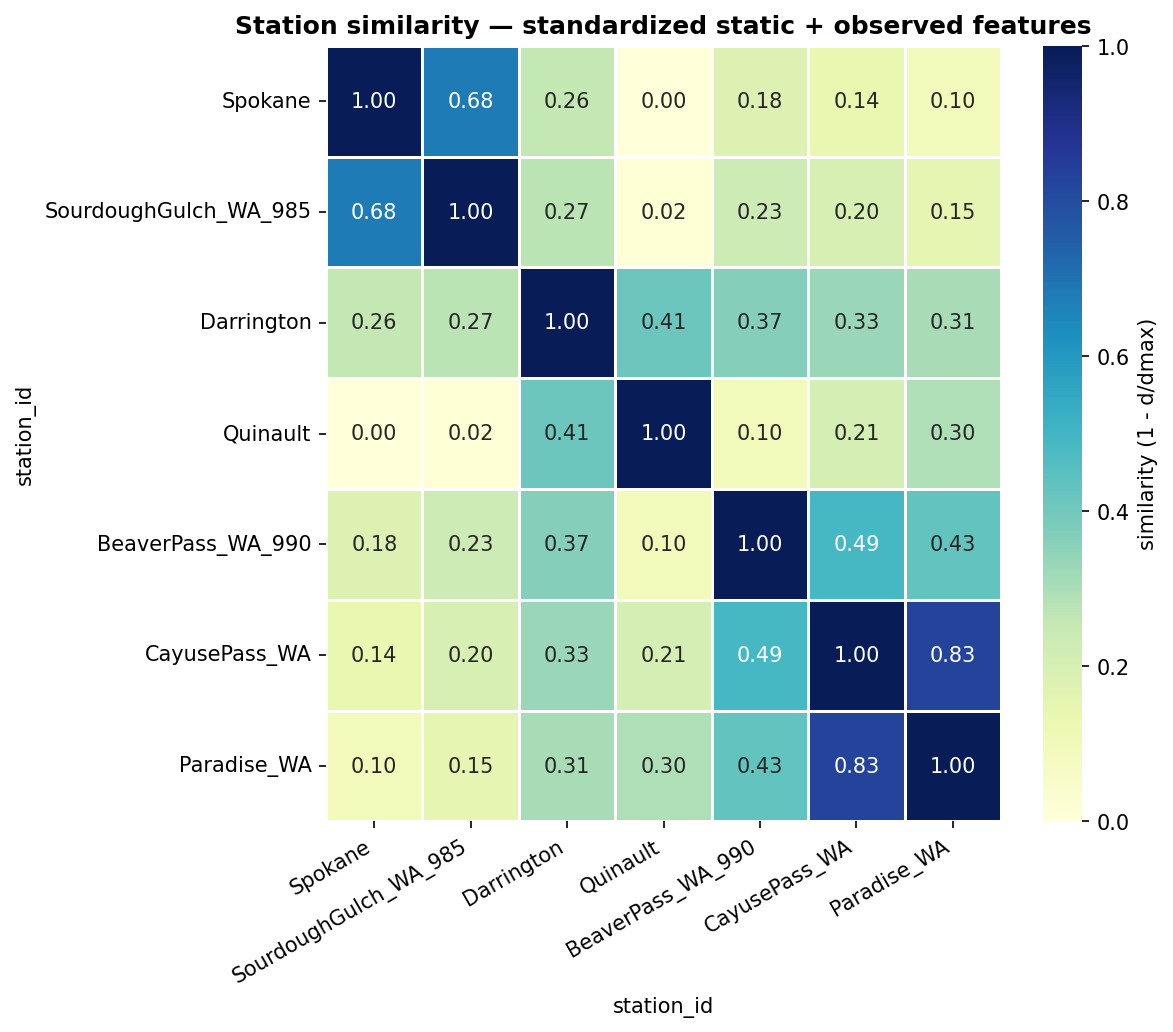

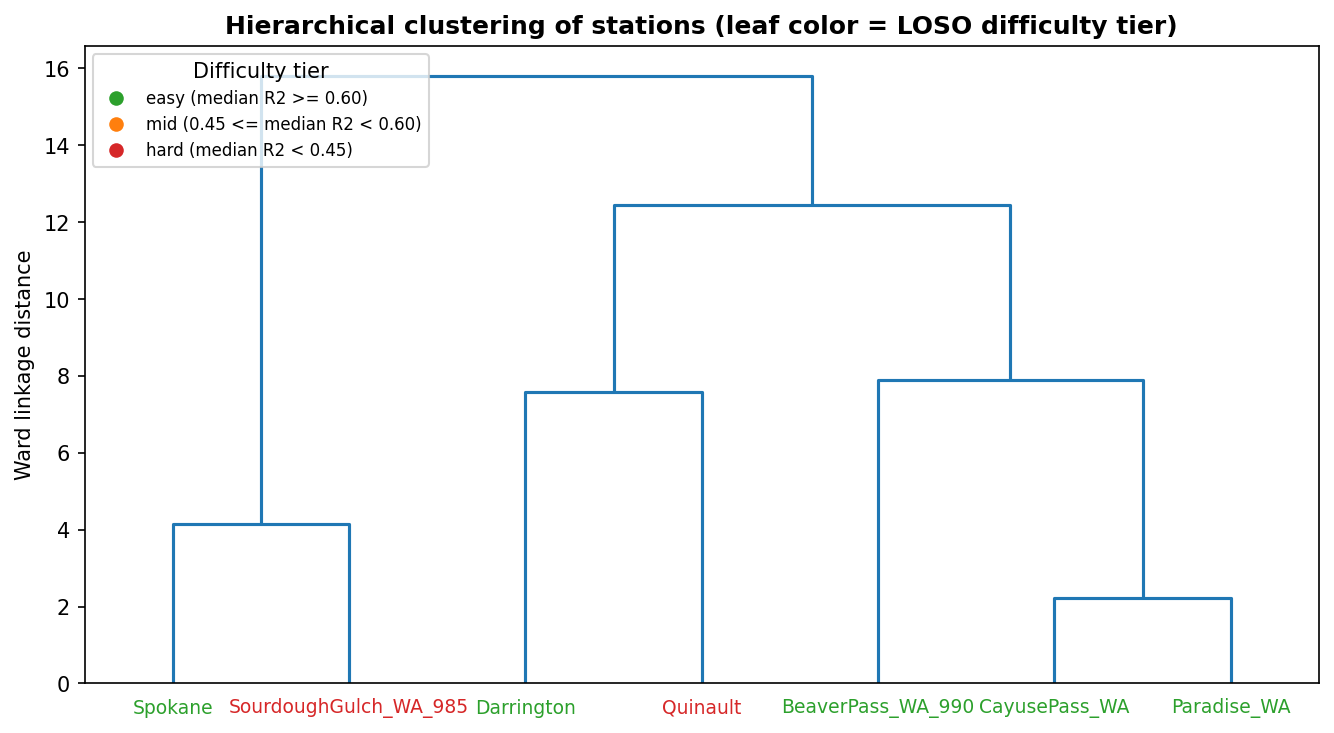

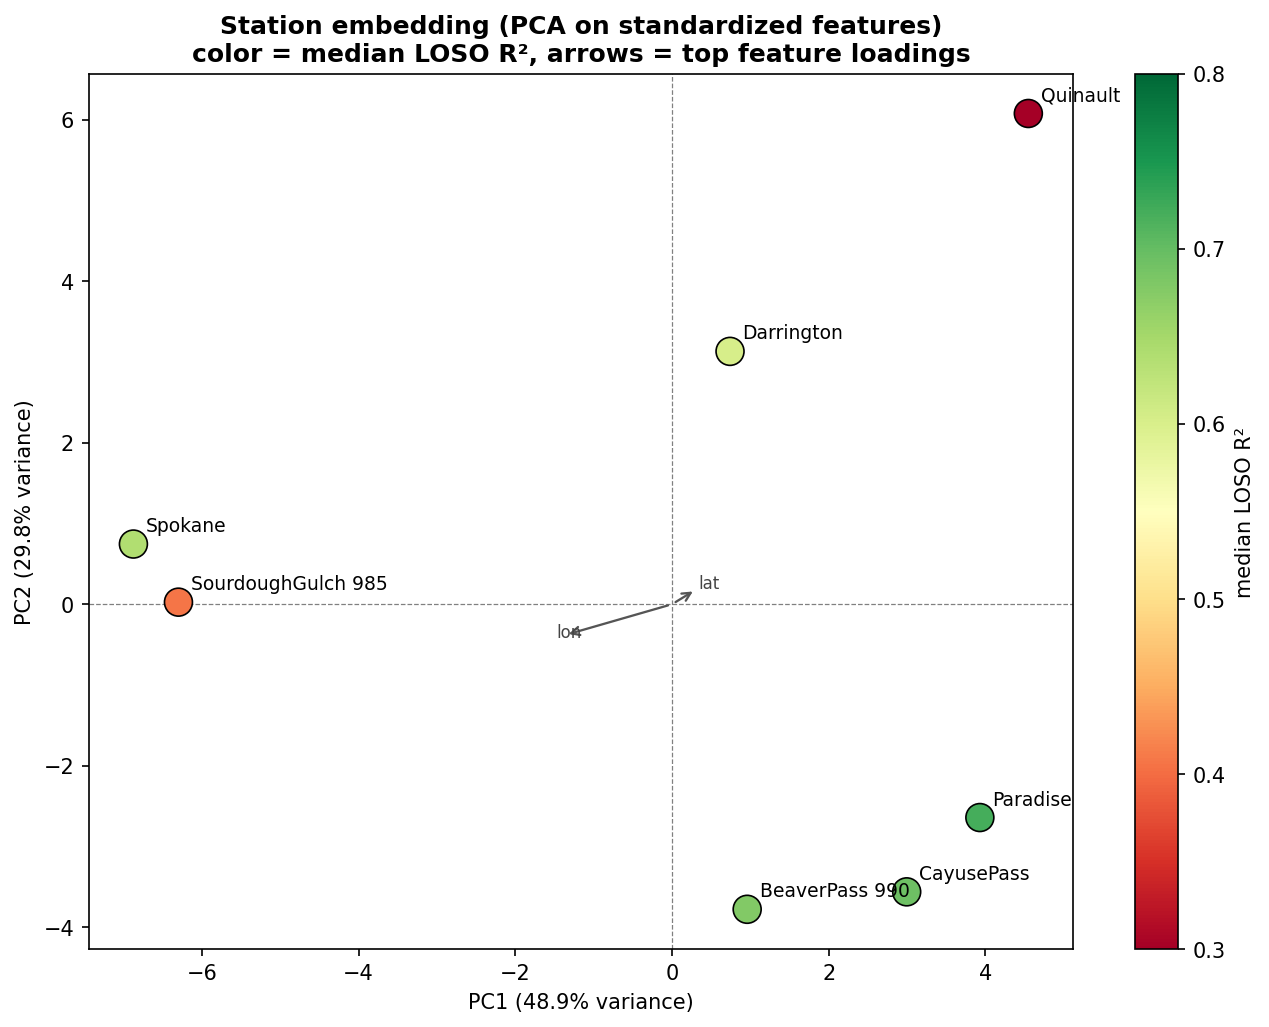

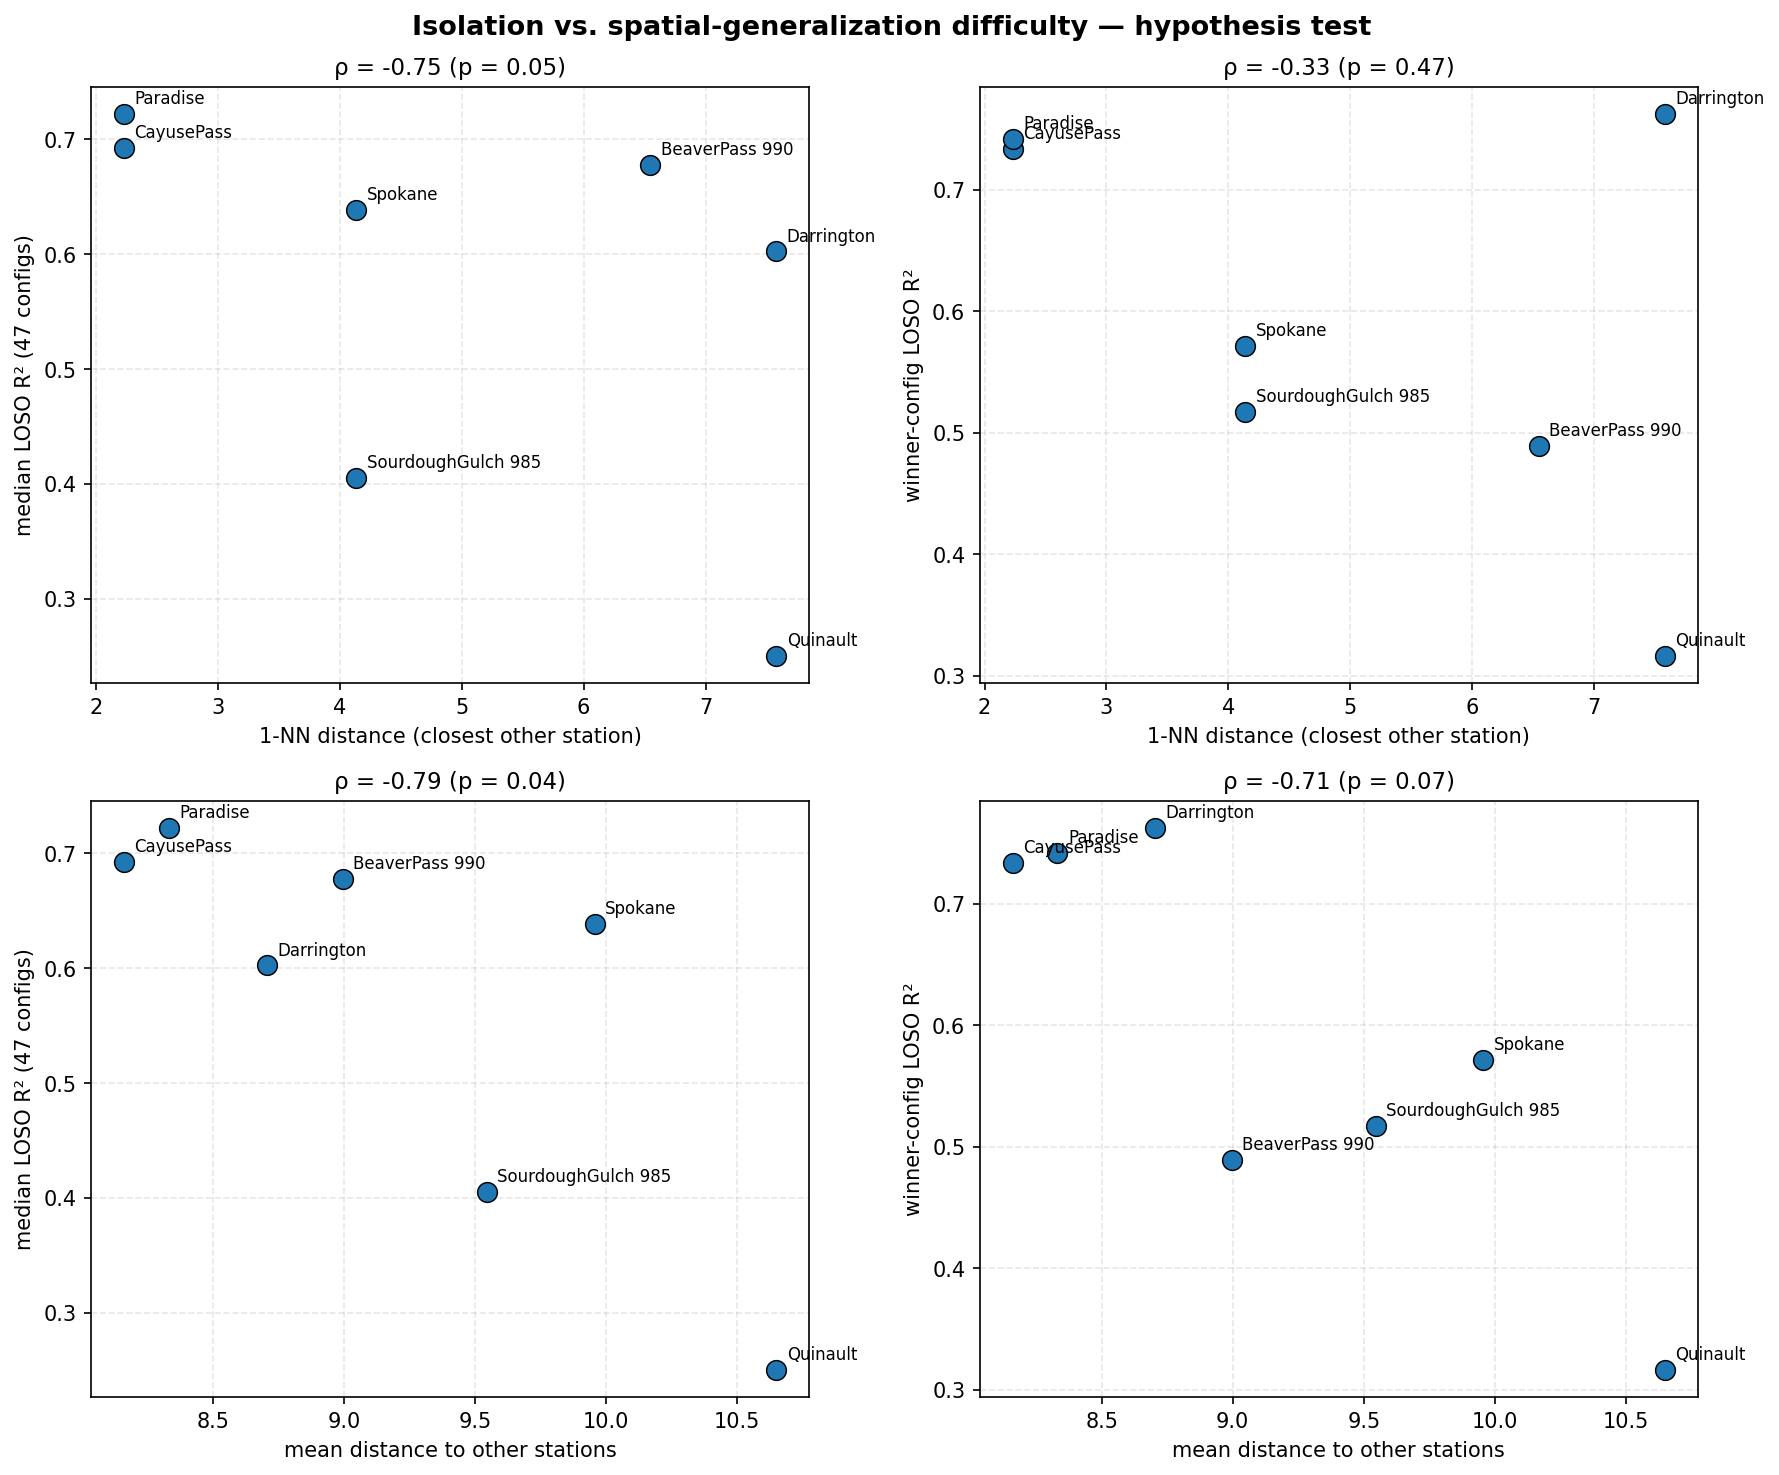

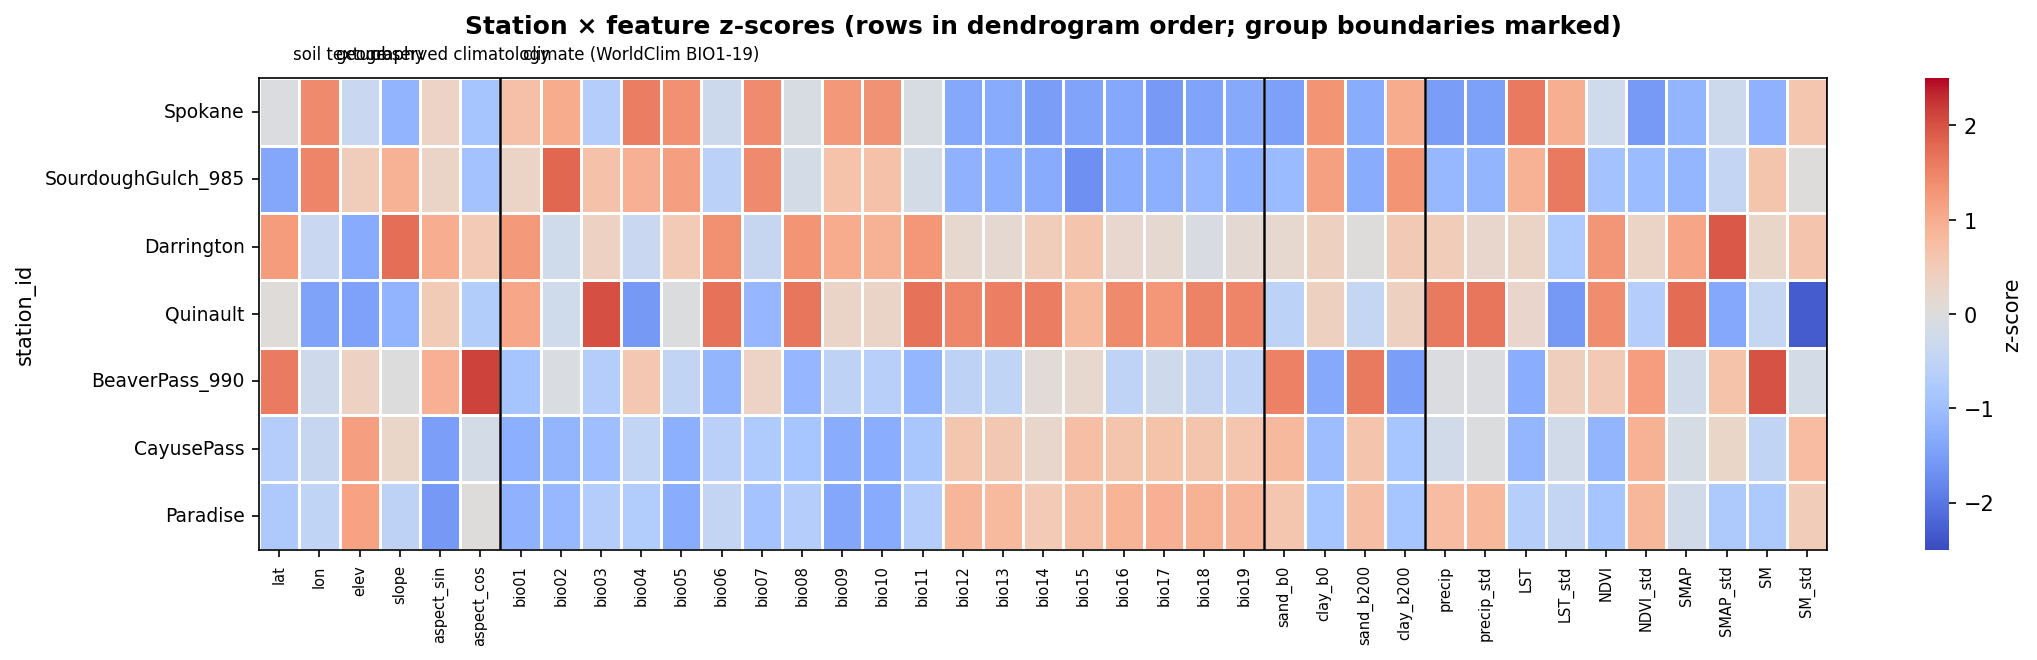

Saved 5 station-similarity figures to the experiment directory.


In [13]:
sim = ss.similarity_matrix(dist)
for fig_path in [
    ss.plot_similarity_heatmap(sim, order, EXP_DIR),
    ss.plot_dendrogram(Z, list(X_std.index), diff, EXP_DIR),
    ss.plot_pca_scatter(scores, ev, loadings, diff, EXP_DIR),
    ss.plot_isolation_vs_difficulty(iso, diff, EXP_DIR),
    ss.plot_feature_heatmap(X_std, order, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 5 station-similarity figures to the experiment directory.")

### Interpretation

The descriptive findings below are computed live by this notebook from the LOSO CSVs; the final conclusions live in the README (populated from this notebook's stdout). The station-similarity structure and the hypothesis-test direction are the same objects eval-1.2 analyzed — what changed is the difficulty measure (now over the 6 MLP configs + 2 XGBoost references, with `winner_r2` = the best 2-regime MLP).

## Full-Training Baseline — Intrinsic vs. Generalization Difficulty

LOSO measures how well a model *generalizes* to a station it never saw during training. To separate **intrinsic** difficulty (hard to fit even when the station's own rows are in the training set) from **generalization-limited** difficulty (easy when trained on, degrades when held out), every MLP configuration was also trained **without LOSO** — router and specialists fit on ALL 7 stations (the mlp-1.3 / mlp-1.1 temporal protocol: train on train 2017–2020, early-stop on val 2021–2022) and evaluated per station on the test set (`run_full_baseline.py`). Because the per-family seeds match the source experiments, each configuration's pooled test R² must replicate its temporal reference (mlp-1.3 / mlp-1.1) — validating the baseline.

In [14]:
df_full_pcs = pd.read_csv(EXP_DIR / "full_per_config_station.csv")
df_full_summary = pd.read_csv(EXP_DIR / "full_config_summary.csv")
df_full_station = pd.read_csv(EXP_DIR / "full_station_summary.csv")

valid = df_full_summary.dropna(subset=["mlp13_test_r2"])
print(f"Validation vs mlp-1.3 / mlp-1.1: {len(valid)} configs compared, "
      f"max |full_pooled_r2 − temporal reference| = {valid['r2_diff'].max():.6f}")

full_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
             "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("\n### Station difficulty under FULL training (intrinsic; median over configs)")
print(df_full_station[full_cols].to_markdown(index=False))

Validation vs mlp-1.3 / mlp-1.1: 6 configs compared, max |full_pooled_r2 − temporal reference| = 0.068630

### Station difficulty under FULL training (intrinsic; median over configs)
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |   min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|---------:|---------:|------------:|------------:|----------------:|
| Spokane               |           6 |           5382 |    0.919756 |  0.90739  | 0.0429886 | 0.823188 | 0.942374 |   0.0343089 |  0.0109466  |               0 |
| Darrington            |           6 |           5994 |    0.815179 |  0.800286 | 0.0498072 | 0.717701 | 0.85409  |   0.0414969 |  0.00949706 |               0 |
| CayusePass_WA         |           6 |           6486 |    0.743603 |  0.736088 | 0.027702  | 0.681841 | 0.756686 |   0.0612889 | -0.00205458 |               0 |
| 

In [15]:
cmp = df_full_station[["station", "median_r2", "mean_r2"]].merge(
    df_station[["station", "median_r2", "mean_r2"]],
    on="station", suffixes=("_full", "_loso"),
)
cmp["gap_median"] = cmp["median_r2_full"] - cmp["median_r2_loso"]
cmp["gap_mean"] = cmp["mean_r2_full"] - cmp["mean_r2_loso"]
cmp = cmp.sort_values("median_r2_loso", ascending=False)
cols = ["station", "median_r2_full", "median_r2_loso", "gap_median",
        "mean_r2_full", "mean_r2_loso", "gap_mean"]
print("### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)")
print(cmp[cols].round(3).to_markdown(index=False))

### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)
| station               |   median_r2_full |   median_r2_loso |   gap_median |   mean_r2_full |   mean_r2_loso |   gap_mean |
|:----------------------|-----------------:|-----------------:|-------------:|---------------:|---------------:|-----------:|
| Paradise_WA           |            0.709 |            0.722 |       -0.013 |          0.683 |          0.723 |     -0.041 |
| CayusePass_WA         |            0.744 |            0.693 |        0.051 |          0.736 |          0.644 |      0.092 |
| BeaverPass_WA_990     |            0.572 |            0.678 |       -0.106 |          0.559 |          0.648 |     -0.089 |
| Spokane               |            0.92  |            0.639 |        0.281 |          0.907 |          0.639 |      0.268 |
| Darrington            |            0.815 |            0.602 |        0.213 |          0.8   |          0.557 |      0.244 |
| SourdoughGulch_WA_985 |            0.4

In [16]:
from scipy.stats import spearmanr
rho, p = spearmanr(cmp["median_r2_full"], cmp["median_r2_loso"])
print(f"Spearman(full median R², LOSO median R²) = {rho:+.3f} (p = {p:.3f}, n = {len(cmp)})")
print("High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.")

Spearman(full median R², LOSO median R²) = +0.250 (p = 0.589, n = 7)
High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.


### Figures

Three figures compare the two difficulty measures: (1) scatter of per-station median R² (full vs LOSO) with the identity line, (2) paired bars per station sorted by LOSO difficulty, and (3) per-station boxplot of the per-configuration LOSO cost (full-training R² − LOSO R²).

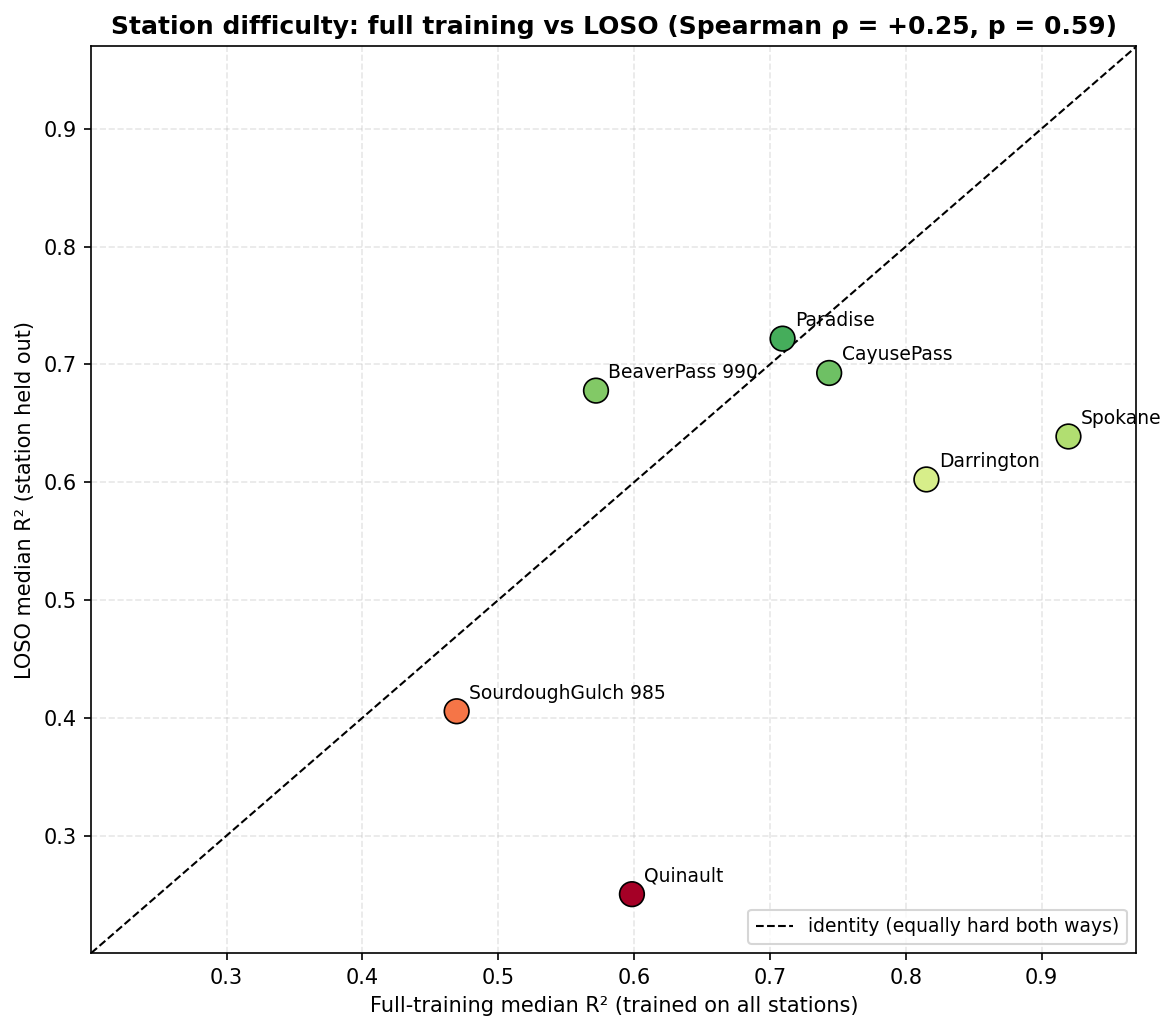

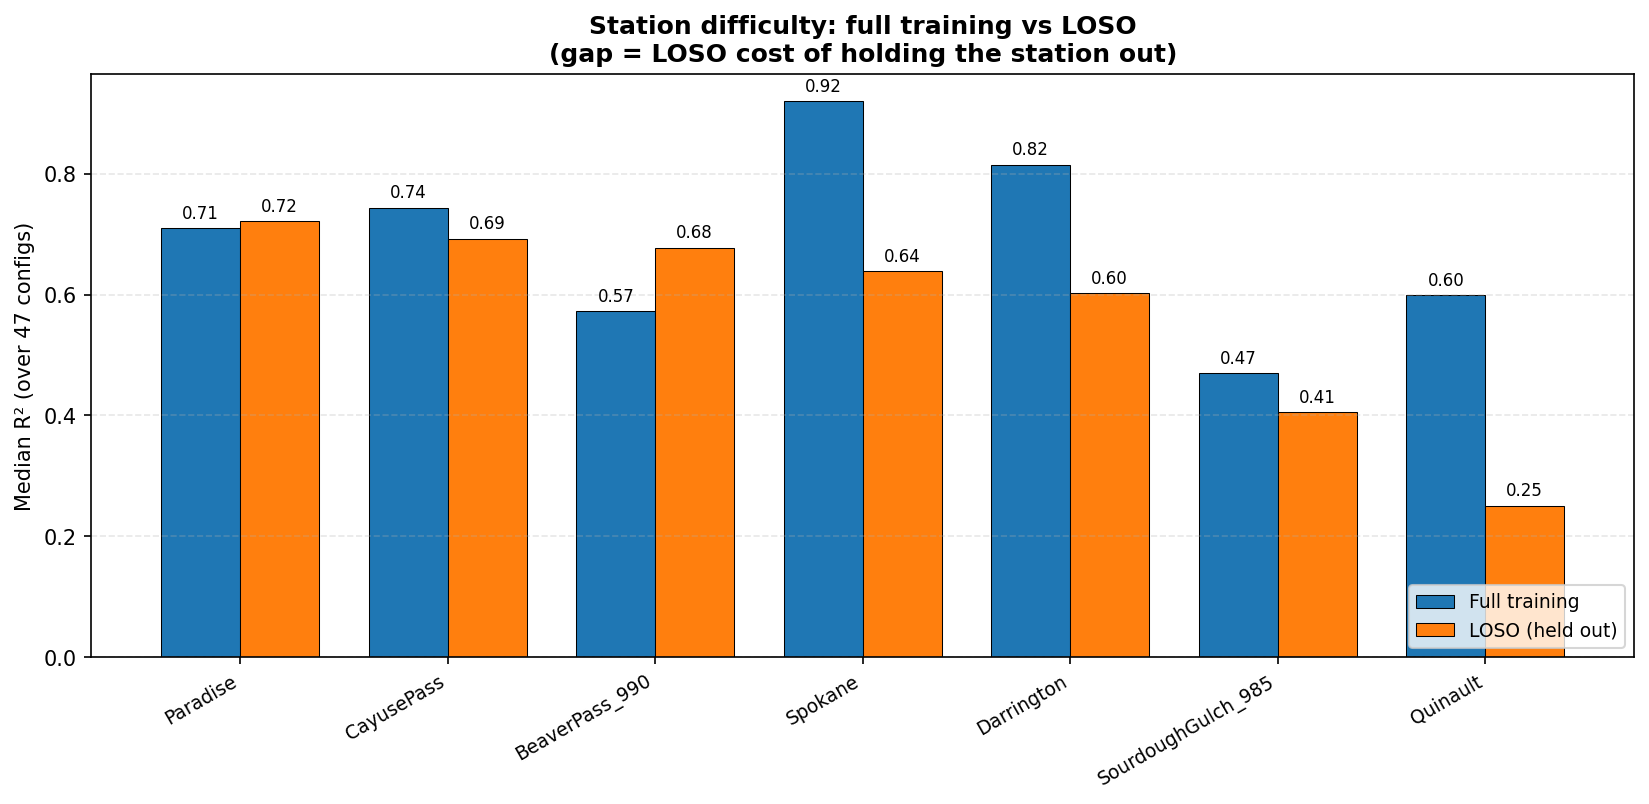

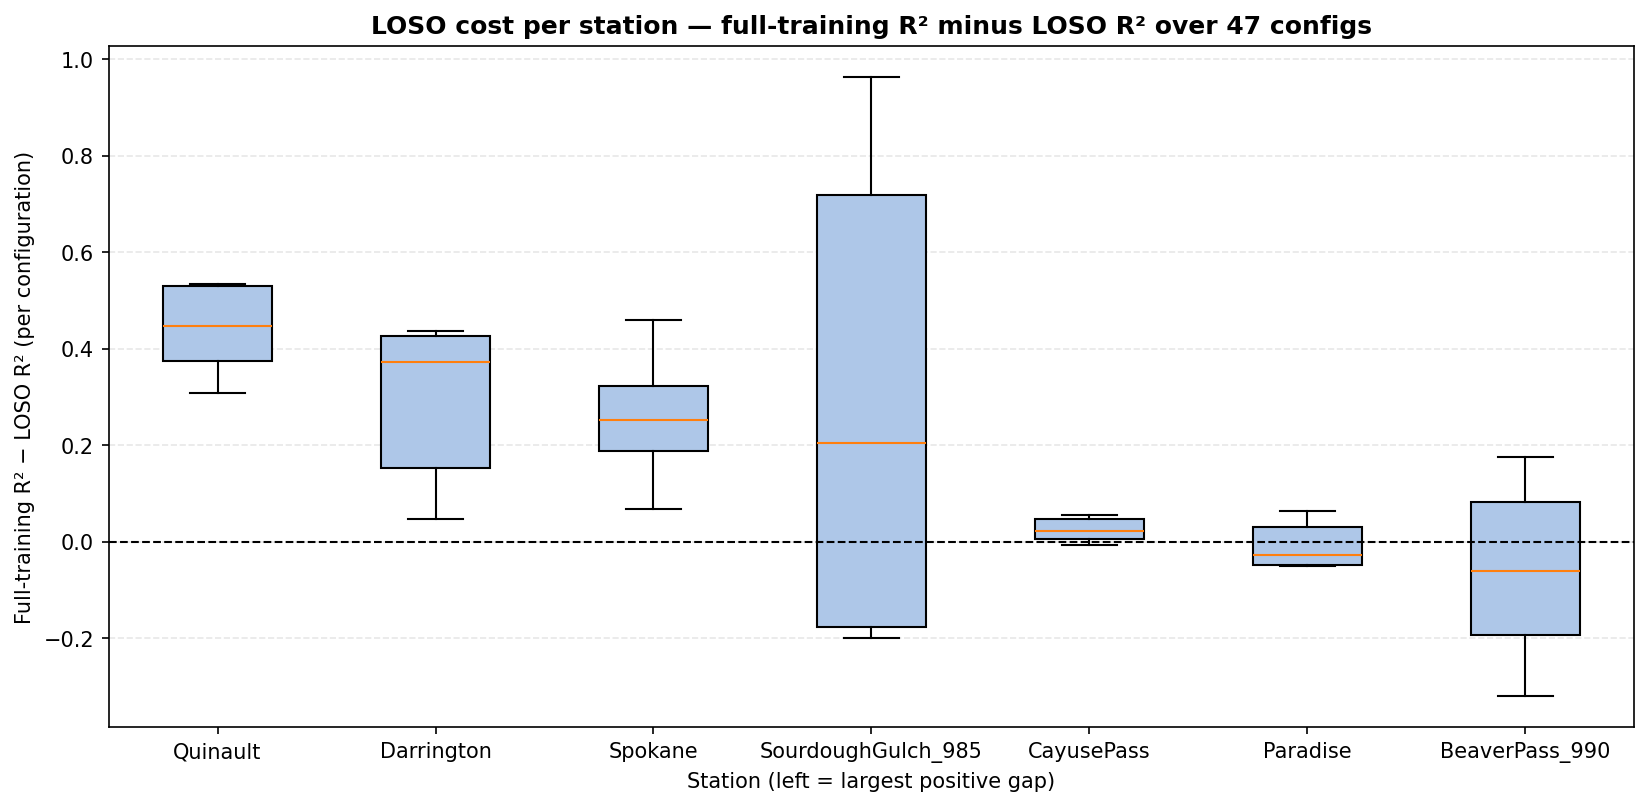

Saved 3 full-baseline comparison figures.


In [17]:
import sys
sys.path.insert(0, str(EXP_DIR.resolve()))
from eval20.plots import plot_full_vs_loso_scatter, plot_full_vs_loso_bars, plot_loso_gap_boxplot

cmp_plot = cmp.rename(columns={"median_r2_full": "full_median_r2", "median_r2_loso": "loso_median_r2"})
for fig_path in [
    plot_full_vs_loso_scatter(cmp_plot, EXP_DIR),
    plot_full_vs_loso_bars(cmp_plot, EXP_DIR),
    plot_loso_gap_boxplot(df_full_pcs, df_pcs, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 3 full-baseline comparison figures.")


### Interpretation

The full-training baseline validates the MLP protocol end-to-end (pooled test R² replicates the mlp-1.3 / mlp-1.1 temporal references). Comparing the two difficulty measures separates generalization-limited stations (large positive `gap_median`: easy when trained on, degrades when held out) from intrinsically hard ones (gap near zero). The same three station archetypes eval-1.2 found with XGBoost — CayusePass as generalization-limited, SourdoughGulch as intrinsically hard, BeaverPass as the LOSO-favorable anomaly — are revisited here under the MLP difficulty measure.